In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [2]:
df = pd.read_csv(r"C:\Users\Hello\Downloads\12701117-Swiggy_Delivery_Time_Prediction\Swiggy Delivery Time Prediction\data\swiggy_demographic (1).csv")
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


## 3. Basic Inspection

In [3]:
df.shape

(45502, 26)

In [4]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  object 
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  object 
 8   weather               44977 non-null  object 
 9   traffic               44992 non-null  object 
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  object 
 12  type_of_vehicle       45502 non-null  object 
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  object 
 15  city_type          

In [6]:
df.isnull().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [7]:
(df.isnull().sum() / len(df)) * 100

rider_id                0.000000
age                     4.074546
ratings                 4.193222
restaurant_latitude     7.977671
restaurant_longitude    7.977671
delivery_latitude       7.977671
delivery_longitude      7.977671
order_date              0.000000
weather                 1.153795
traffic                 1.120830
vehicle_condition       0.000000
type_of_order           0.000000
type_of_vehicle         0.000000
multiple_deliveries     2.182322
festival                0.501077
city_type               2.632851
time_taken              0.000000
city_name               0.000000
order_day               0.000000
order_month             0.000000
order_day_of_week       0.000000
is_weekend              0.000000
pickup_time_minutes     3.604237
order_time_hour         3.604237
order_time_of_day       0.000000
distance                7.977671
dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df.describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,44509.000000,45502.000000,45502.000000,45502.000000,45502.000000,43862.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,1.019406,0.744928,26.297591,13.811657,2.980726,0.274867,9.989399,17.423966,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,0.835229,0.572488,9.386419,8.709540,0.546031,0.446452,4.087516,4.817856,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.000000,2.000000,0.000000,5.000000,0.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,0.000000,0.000000,19.000000,6.000000,3.000000,0.000000,5.000000,15.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,1.000000,1.000000,26.000000,13.000000,3.000000,0.000000,10.000000,19.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000,32.000000,20.000000,3.000000,1.000000,15.000000,21.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000,31.000000,4.000000,1.000000,15.000000,23.000000,20.969489


In [11]:
df.nunique()

rider_id                1320
age                       20
ratings                   26
restaurant_latitude      388
restaurant_longitude     388
delivery_latitude       4362
delivery_longitude      4362
order_date                44
weather                    6
traffic                    4
vehicle_condition          4
type_of_order              4
type_of_vehicle            4
multiple_deliveries        4
festival                   2
city_type                  3
time_taken                45
city_name                 22
order_day                 30
order_month                3
order_day_of_week          7
is_weekend                 2
pickup_time_minutes        3
order_time_hour           17
order_time_of_day          5
distance                4362
dtype: int64

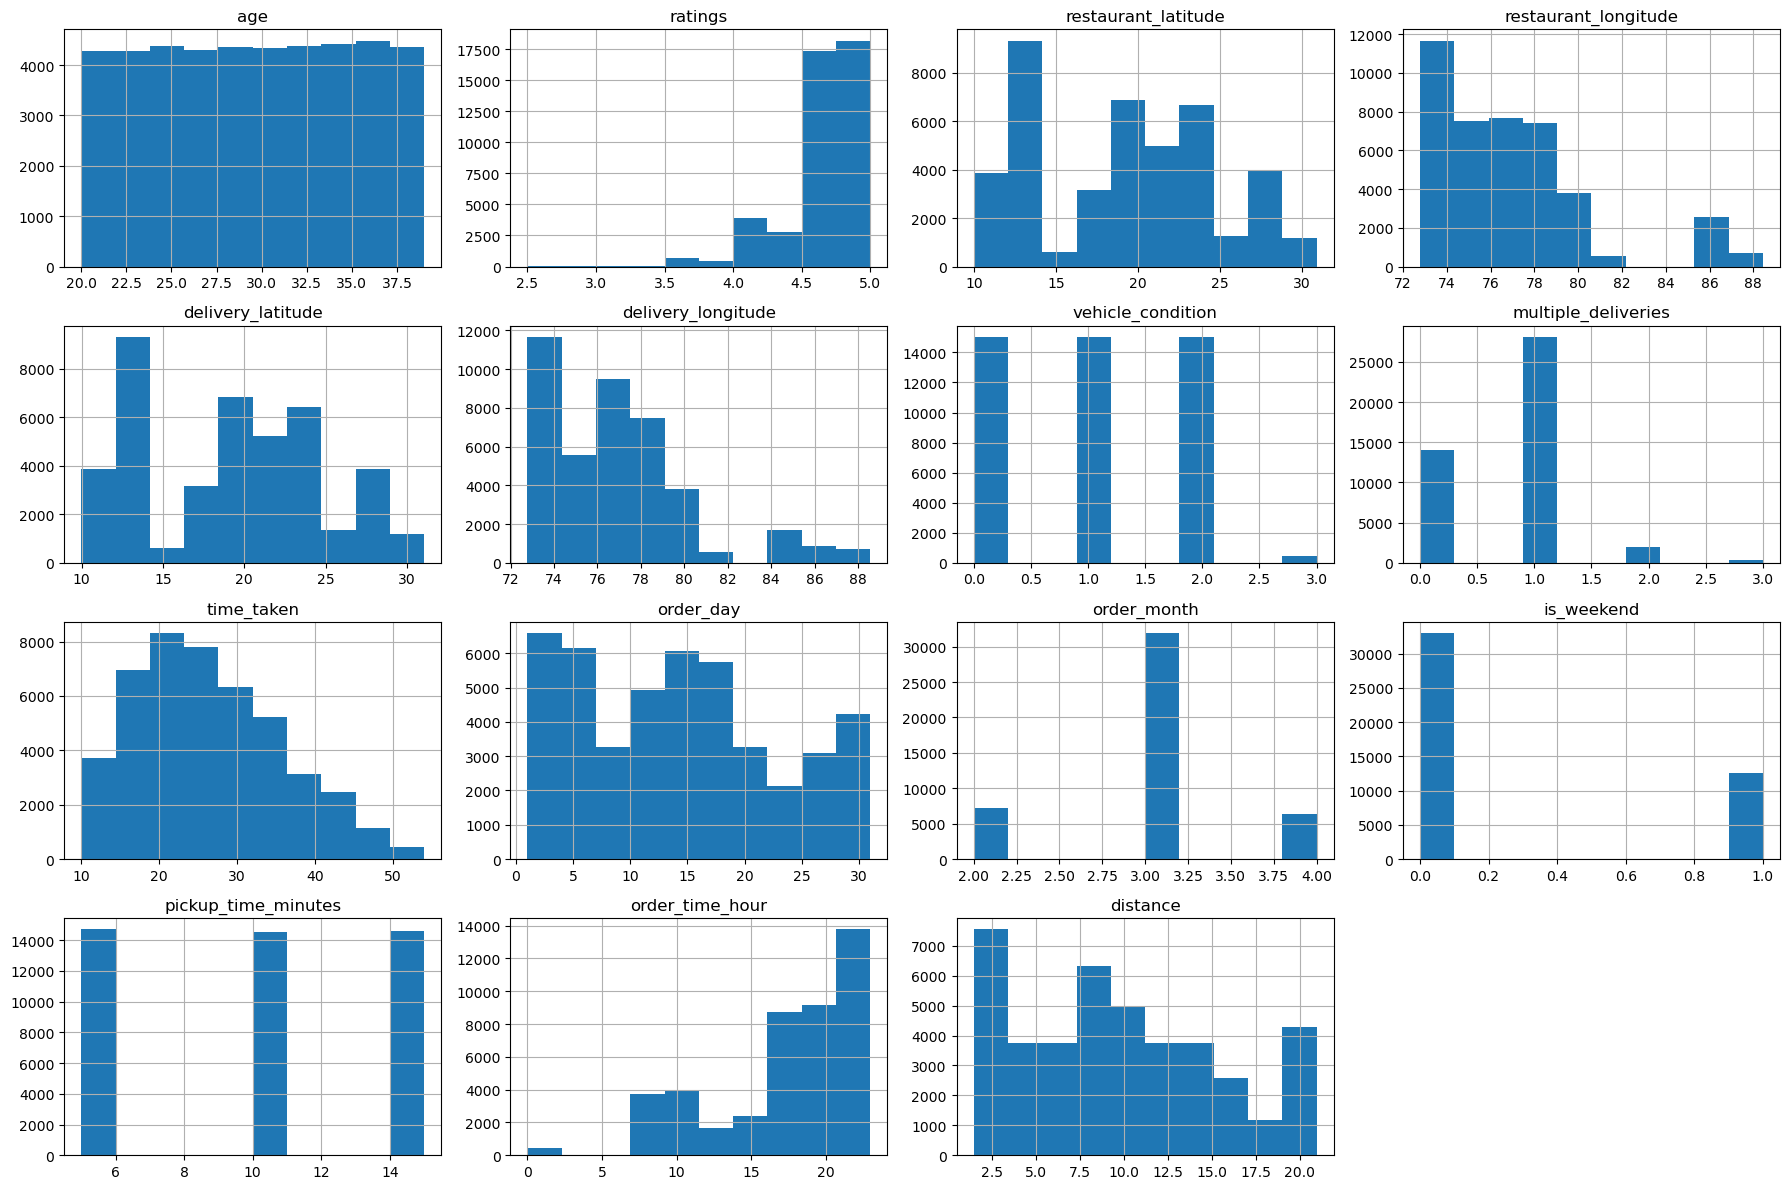

In [12]:
df.hist(figsize=(18,12))
plt.tight_layout()
plt.show()

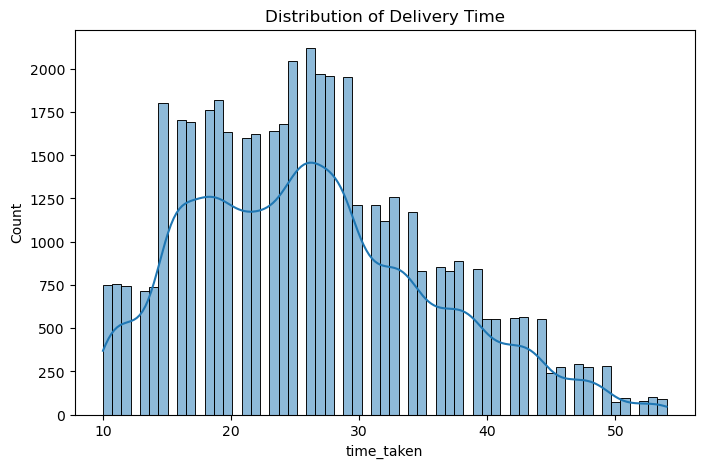

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["time_taken"], kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

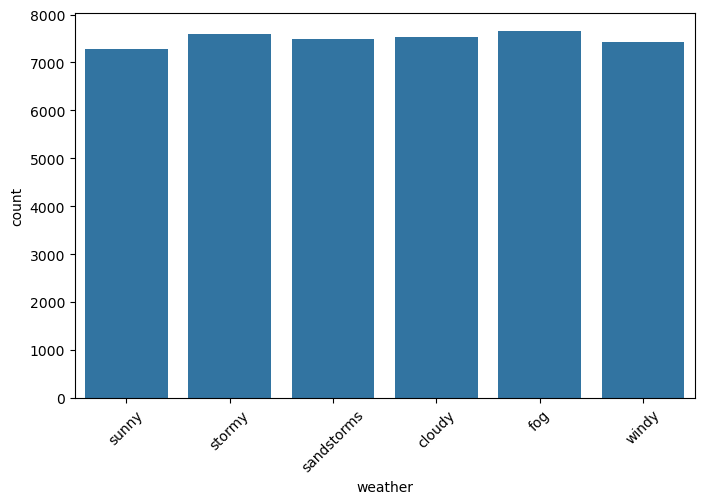

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x="weather", data=df)
plt.xticks(rotation=45)
plt.show()

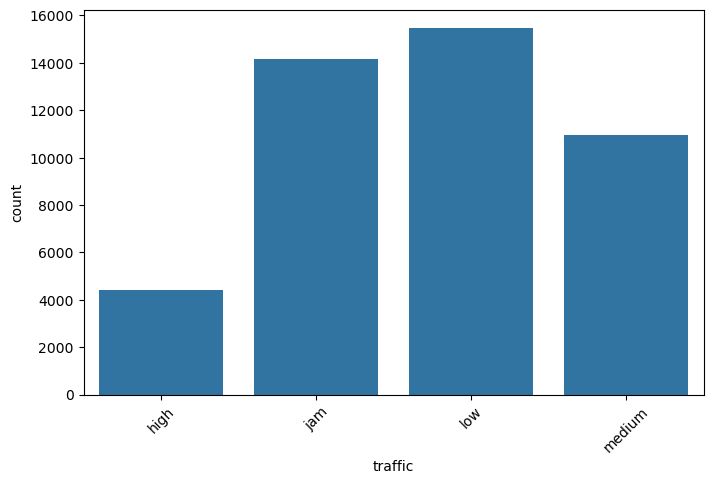

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x="traffic", data=df)
plt.xticks(rotation=45)
plt.show()

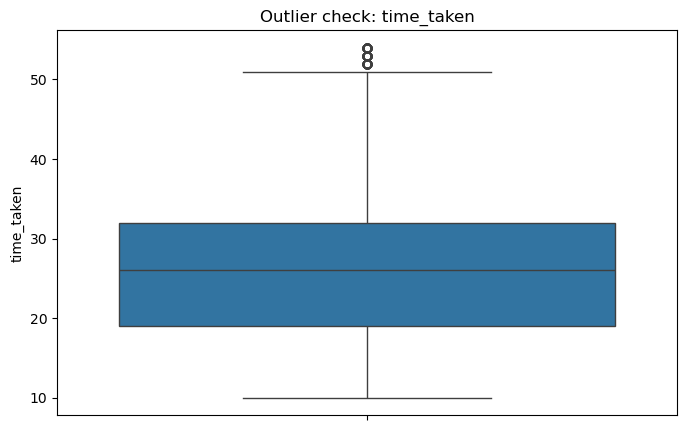

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["time_taken"])
plt.title("Outlier check: time_taken")
plt.show()

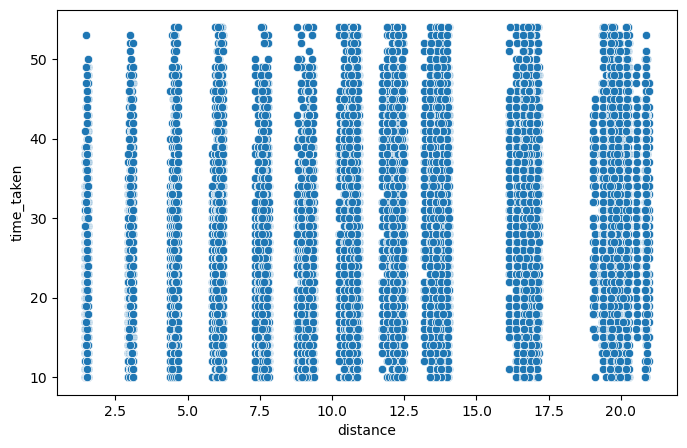

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="distance", y="time_taken", data=df)
plt.show()

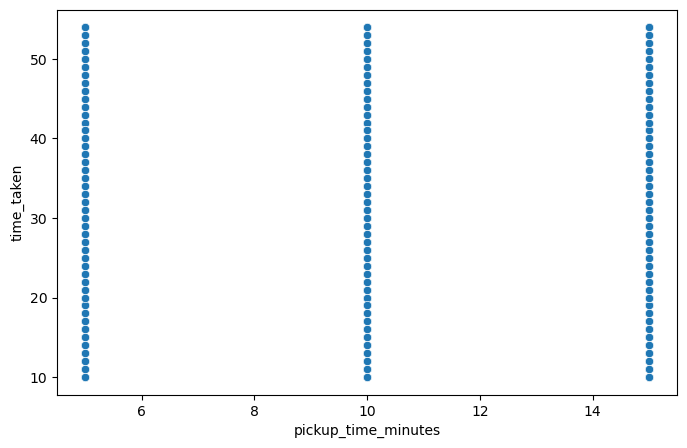

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="pickup_time_minutes", y="time_taken", data=df)
plt.show()

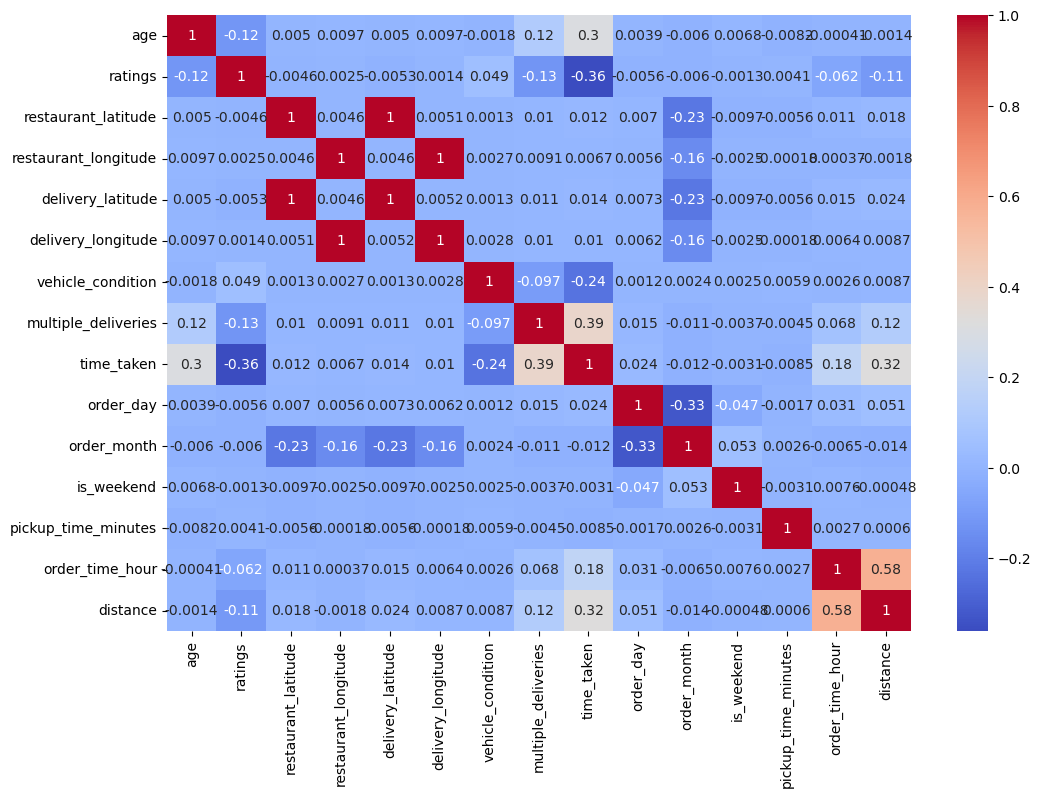

In [19]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=["int64","float64"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [20]:
x = df.drop(columns=["time_taken", "rider_id", "order_date"])
y = df["time_taken"]

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)
print(x_train.shape, x_test.shape)

(36401, 23) (9101, 23)


In [22]:
num_cols = x_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
ordinal_cols = ["traffic", "order_time_of_day", "city_type"]
onehot_cols = [c for c in x_train.select_dtypes(include=["object"]).columns if c not in ordinal_cols]

print("Numeric:", num_cols)
print("Ordinal:", ordinal_cols)
print("One-hot:", onehot_cols)

Numeric: ['age', 'ratings', 'restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude', 'vehicle_condition', 'multiple_deliveries', 'order_day', 'order_month', 'is_weekend', 'pickup_time_minutes', 'order_time_hour', 'distance']
Ordinal: ['traffic', 'order_time_of_day', 'city_type']
One-hot: ['weather', 'type_of_order', 'type_of_vehicle', 'festival', 'city_name', 'order_day_of_week']


In [23]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

traffic_order = ["low", "medium", "high", "jam"]
time_order = ["after_midnight", "morning", "afternoon", "evening", "night"]
city_order = ["semi-urban", "urban", "metropolitian"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[traffic_order, time_order, city_order],
                                handle_unknown="use_encoded_value", unknown_value=-1))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("cat", onehot_pipeline, onehot_cols)
])

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}\n  MSE : {mse:.3f}\n  RMSE: {rmse:.3f}\n  MAE : {mae:.3f}\n  R2  : {r2:.4f}\n")
    return {"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2 Score": r2}

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor()
}

results = []
fitted_pipes = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(x_train, y_train)
    pred = pipe.predict(x_test)
    results.append(evaluate(name, y_test, pred))
    fitted_pipes[name] = pipe

Linear Regression
  MSE : 37.983
  RMSE: 6.163
  MAE : 4.917
  R2  : 0.5682

Decision Tree
  MSE : 32.124
  RMSE: 5.668
  MAE : 4.309
  R2  : 0.6348

Random Forest
  MSE : 17.333
  RMSE: 4.163
  MAE : 3.295
  R2  : 0.8029

Gradient Boosting
  MSE : 22.197
  RMSE: 4.711
  MAE : 3.746
  R2  : 0.7476

KNN Regressor
  MSE : 41.392
  RMSE: 6.434
  MAE : 5.039
  R2  : 0.5294



In [26]:
result_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
result_df

,Model,MSE,RMSE,MAE,R2 Score
0,Random Forest,17.332726,4.163259,3.294575,0.802950
1,Gradient Boosting,22.197205,4.711391,3.746175,0.747647
2,Decision Tree,32.123503,5.667760,4.308538,0.634798
3,Linear Regression,37.983227,6.163053,4.916924,0.568181
4,KNN Regressor,41.391724,6.433640,5.039402,0.529431


In [27]:
from sklearn.model_selection import cross_val_score

rf_pipe = Pipeline([("preprocessor", preprocessor),
                     ("model", RandomForestRegressor(random_state=42, n_jobs=-1))])

cv_scores = cross_val_score(rf_pipe, x_train, y_train, cv=5, scoring="r2", n_jobs=-1)
print("Cross Validation Scores :", cv_scores)
print("Average R2 Score :", cv_scores.mean())

Cross Validation Scores : [0.79892028 0.79893721 0.79721169 0.796878   0.79374502]
Average R2 Score : 0.7971384414332194


### Observation
The Random Forest model was evaluated using 5-fold cross-validation on the **training set only** (test set stays untouched until final evaluation). The average R² indicates how consistently the model performs across different subsets of the training data.

In [28]:
import optuna

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 300)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    score = cross_val_score(pipe, x_train, y_train, cv=5, scoring="r2", n_jobs=1).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-08-17 15:58:11,284] A new study created in memory with name: no-name-db12b0d9-4ba5-4ece-967d-b0d85445bc40
[I 2026-08-17 16:01:29,294] Trial 0 finished with value: 0.7988363413969959 and parameters: {'n_estimators': 224, 'max_depth': 23, 'min_samples_split': 5}. Best is trial 0 with value: 0.7988363413969959.
[I 2026-08-17 16:04:01,849] Trial 1 finished with value: 0.7998327896329672 and parameters: {'n_estimators': 188, 'max_depth': 24, 'min_samples_split': 9}. Best is trial 1 with value: 0.7998327896329672.
[I 2026-08-17 16:06:07,641] Trial 2 finished with value: 0.797407677302045 and parameters: {'n_estimators': 125, 'max_depth': 28, 'min_samples_split': 2}. Best is trial 1 with value: 0.7998327896329672.
[I 2026-08-17 16:08:48,836] Trial 3 finished with value: 0.7980360351920127 and parameters: {'n_estimators': 168, 'max_depth': 29, 'min_samples_split': 3}. Best is trial 1 with value: 0.7998327896329672.
[I 2026-08-17 16:11:52,540] Trial 4 finished with value: 0.801300355923

In [29]:
print("Best Parameters:", study.best_params)
print("Best CV Score :", study.best_value)

Best Parameters: {'n_estimators': 210, 'max_depth': 13, 'min_samples_split': 8}
Best CV Score : 0.8014057538879674


## 12. Final Model — trained once, evaluated once
(The original notebook built `best_model` twice and ran the metrics cell twice — with the second run accidentally reusing the *first* run's `predict` variable. Here it's built and evaluated exactly once.)

In [30]:
best_model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)

final_pipe = Pipeline([("preprocessor", preprocessor), ("model", best_model)])
final_pipe.fit(x_train, y_train)

final_prediction = final_pipe.predict(x_test)
final_metrics = evaluate("Tuned Random Forest", y_test, final_prediction)

Tuned Random Forest
  MSE : 16.951
  RMSE: 4.117
  MAE : 3.264
  R2  : 0.8073



In [31]:
train_score = final_pipe.score(x_train, y_train)
test_score = final_pipe.score(x_test, y_test)

print("Training R2 :", train_score)
print("Testing R2  :", test_score)
print("Gap         :", train_score - test_score)

Training R2 : 0.8582413494112417
Testing R2  : 0.8072866987072055
Gap         : 0.050954650704036264


In [32]:
feature_names = final_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = final_pipe.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
1,num__ratings,0.221907
14,ord__traffic,0.139321
7,num__multiple_deliveries,0.134009
13,num__distance,0.094320
0,num__age,0.094069
20,cat__weather_sunny,0.080656
6,num__vehicle_condition,0.077303
17,cat__weather_fog,0.035007
18,cat__weather_sandstorms,0.020737
28,cat__festival_yes,0.019393


In [33]:
with open("swiggy_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipe, f)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [34]:
with open("swiggy_pipeline.pkl", "rb") as f:
    loaded_pipe = pickle.load(f)

print(loaded_pipe.predict(x_test.head()))

[20.66788063 28.09111758 14.6177609  23.19304918 17.06439191]
